In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

# Inter-annotator aggreement (6-level annotation)
## Cohen Kappa score for all test annotations combined

- Test1 - 19 utterances
- Test2 - 50 utterances
- Test3 - 50 utterances

Importing the consolidation files to analyze all: IAA (Cohen's Kappa), Final tag comparison, label distribution between the annotators (all procedural and non-procedural)

In [11]:
test1 = pd.read_excel('Test1/Test1_consolidation.xlsx')
test2 = pd.read_excel('Test2/Test2_consolidation.xlsx')
test3 = pd.read_excel('Test3/Test3_consolidation.xlsx')

In [12]:
test3.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2004-01-27-SDZ3-Redna-33.u194,"Magister Drobnič, ste želeli besedo? Prosim.",P_Neutral,P_Neutral,Procedural.,Procedural,NaN,NaN,True,P_Neutral
1,ParlaMint-SI_2015-07-14-SDZ7-Redna-10.u428,"Gospa Anja Bah Žibert, imate besedo, da zahtev...",P_Neutral,P_Neutral,Procedural.,Procedural,NaN,NaN,True,P_Neutral
2,ParlaMint-SI_2008-03-05-SDZ4-Izredna-34.u28,Hvala lepa. No sedaj smo pravzaprav lahko vide...,Negative,Negative,"Clear sentiment, negative opinion, reproachful...","Very negative, attack on the minister and crit...",NaN,NaN,False,Negative
3,ParlaMint-SI_2006-05-24-SDZ4-Redna-17.u82,Hvala lepa. Samo na kratko. Vlada podpira aman...,Positive,P_Neutral,Since the word ''podpira'' is used I would say...,"Very neutral, procedural - support to amend th...",1.0,NaN,False,P_Neutral
4,ParlaMint-SI_2002-09-24-SDZ3-Redna-18.u52,"Spoštovana predsedujoča! Gospa ministrica, kol...",M_Negative,M_Negative,A very mixed sentiment sentence. On the one ha...,Speaker takes a position of having the topic o...,1.0,1.0,False,M_Negative


In [13]:
test1 = test1.rename(columns={'tamara_tag':'tag_tamara', 'katja_tag':'tag_katja', 'tamara_comments':'comments_tamara', 'katja_comments':'comments_katja', 
                              'tamara_flagged':'flagged_tamara', 'katja_flagged':'flagged_katja'})
test1.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2004-03-23-SDZ3-Redna-35.u243,"Gospod predsednik, ker je bil k predlogu zakon...",P_Neutral,P_Neutral,"No actual sentiment, purely a neutral request ...","Procedural, very neutral.",NaN,NaN,NaN,P_Neutral
1,ParlaMint-SI_2004-04-09-SDZ3-Izredna-42.u44,"Hvala, gospod predsedujoči. Ta amandma, ki smo...",Negative,M_Negative,A hard one. This one definitly couldn't fall u...,The amandment is not sufficiently dealing with...,1.0,NaN,NaN,Negative
2,ParlaMint-SI_2004-03-24-SDZ3-Redna-35.u165,"Hvala. Še enkrat sem se oglasil, čeprav sem mi...",Negative,Negative,"Clear disagreement with the previous speaker, ...",While there are several passages in the speech...,NaN,NaN,NaN,Negative
3,ParlaMint-SI_2004-03-25-SDZ3-Redna-35.u167,Spoštovane kolegice in kolegi. Ko obravnavamo ...,Negative,Negative,Although at first it seemed like it would be a...,"TLDR: I agree to some aspects, but if we do th...",NaN,1.0,NaN,Negative
4,ParlaMint-SI_2004-09-01-SDZ3-Izredna-50.u158,Hvala lepa. Stališče poslanske skupine Demokra...,P_Neutral,P_Neutral,"Nothing special, nothing negative, purely cere...","Procedural, very neutral.",NaN,NaN,1.0,P_Neutral


In [15]:
tests = pd.concat([test1, test2, test3])
tests.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2004-03-23-SDZ3-Redna-35.u243,"Gospod predsednik, ker je bil k predlogu zakon...",P_Neutral,P_Neutral,"No actual sentiment, purely a neutral request ...","Procedural, very neutral.",NaN,NaN,NaN,P_Neutral
1,ParlaMint-SI_2004-04-09-SDZ3-Izredna-42.u44,"Hvala, gospod predsedujoči. Ta amandma, ki smo...",Negative,M_Negative,A hard one. This one definitly couldn't fall u...,The amandment is not sufficiently dealing with...,1.0,NaN,NaN,Negative
2,ParlaMint-SI_2004-03-24-SDZ3-Redna-35.u165,"Hvala. Še enkrat sem se oglasil, čeprav sem mi...",Negative,Negative,"Clear disagreement with the previous speaker, ...",While there are several passages in the speech...,NaN,NaN,NaN,Negative
3,ParlaMint-SI_2004-03-25-SDZ3-Redna-35.u167,Spoštovane kolegice in kolegi. Ko obravnavamo ...,Negative,Negative,Although at first it seemed like it would be a...,"TLDR: I agree to some aspects, but if we do th...",NaN,1.0,NaN,Negative
4,ParlaMint-SI_2004-09-01-SDZ3-Izredna-50.u158,Hvala lepa. Stališče poslanske skupine Demokra...,P_Neutral,P_Neutral,"Nothing special, nothing negative, purely cere...","Procedural, very neutral.",NaN,NaN,1.0,P_Neutral


In [16]:
annotator1 = tests['tag_tamara']
annotator2 = tests['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.7539181541140618)

## Cohens Kappa for non-procedural speech

In [17]:
tests_non = tests[tests['chair'] != True]
len(tests_non)

61

In [18]:
annotator1_non = tests_non['tag_tamara']
annotator2_non = tests_non['tag_katja']
cohen_kappa_score(annotator1_non, annotator2_non)

np.float64(0.6077912254160364)

# Inter-annotator aggreement (3-level annotation)
## IAA for full dataset

In [19]:
tests.loc[(tests['tag_tamara'] == 'Negative') | (tests['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
tests.loc[(tests['tag_tamara'] == 'Positive') | (tests['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
tests.loc[(tests['tag_tamara'] == 'P_Neutral') | (tests['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

tests.loc[(tests['tag_katja'] == 'Negative') | (tests['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
tests.loc[(tests['tag_katja'] == 'Positive') | (tests['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
tests.loc[(tests['tag_katja'] == 'P_Neutral') | (tests['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

In [20]:
annotator1 = tests['sent_tamara']
annotator2 = tests['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.7952310717797444)

## IAA for 3-level annotation for non-procedural only

In [21]:
tests_non.loc[(tests_non['tag_tamara'] == 'Negative') | (tests_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
tests_non.loc[(tests_non['tag_tamara'] == 'Positive') | (tests_non['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
tests_non.loc[(tests_non['tag_tamara'] == 'P_Neutral') | (tests_non['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

tests_non.loc[(tests_non['tag_katja'] == 'Negative') | (tests_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
tests_non.loc[(tests_non['tag_katja'] == 'Positive') | (tests_non['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
tests_non.loc[(tests_non['tag_katja'] == 'P_Neutral') | (tests_non['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_4545/1052513641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tests_non.loc[(tests_non['tag_tamara'] == 'Negative') | (tests_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_4545/1052513641.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tests_non.loc[(tests_non['tag_katja'] == 'Negative') | (tests_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'


In [22]:
annotator1 = tests_non['sent_tamara']
annotator2 = tests_non['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.5935268919562113)

# Label distributions
## Label distribution (all Test datasets)


In [23]:
tests_labels = tests['final_tag'].value_counts()
tests_labels

final_tag
P_Neutral     65
Negative      29
M_Negative    10
Positive       9
M_Positive     4
N_Neutral      2
Name: count, dtype: int64

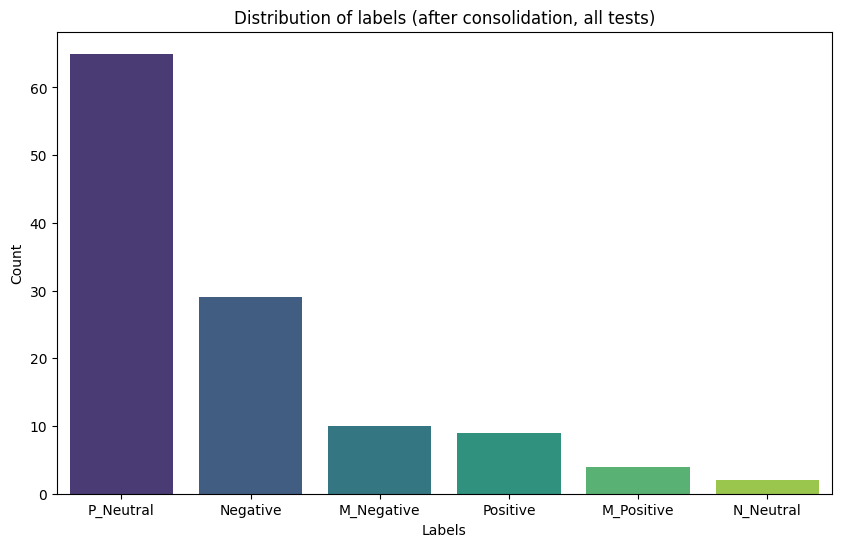

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x=tests_labels.index, y=tests_labels.values, hue=tests_labels.index, palette='viridis', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of labels (after consolidation, all tests)')
plt.show()

## Label distribution (all Test datasets, non-procedural speech)


In [25]:
tests_non_labels = tests_non['final_tag'].value_counts()
tests_non_labels

final_tag
Negative      29
P_Neutral     10
M_Negative     9
Positive       9
M_Positive     4
Name: count, dtype: int64

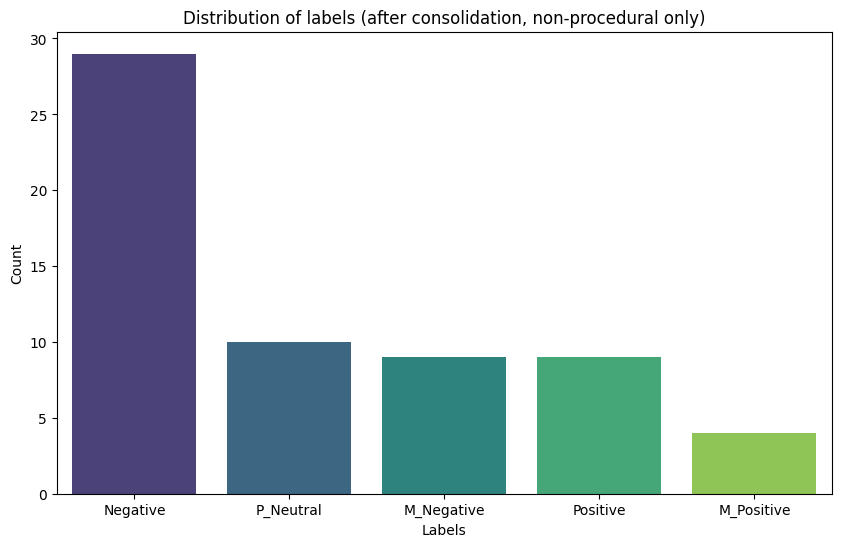

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x=tests_non_labels.index, y=tests_non_labels.values, hue=tests_non_labels.index, palette='viridis', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of labels (after consolidation, non-procedural only)')
plt.show()

# Label distributions per annotators
## Label distributions per annotators (all test datasets)



In [27]:
annotator1_labels = tests['tag_tamara'].value_counts()
annotator2_labels = tests['tag_katja'].value_counts()

In [28]:
df2 = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
}).fillna(0)

In [29]:
df2 = df2.reset_index().rename(columns={'index': 'label'})
df2

,label,annotator1,annotator2
0,M_Negative,6,9
1,M_Positive,4,6
2,N_Neutral,5,3
3,Negative,29,30
4,P_Neutral,62,63
5,Positive,13,8


In [30]:
df2 = df2.melt(id_vars='label', var_name='annotator', value_name='count')

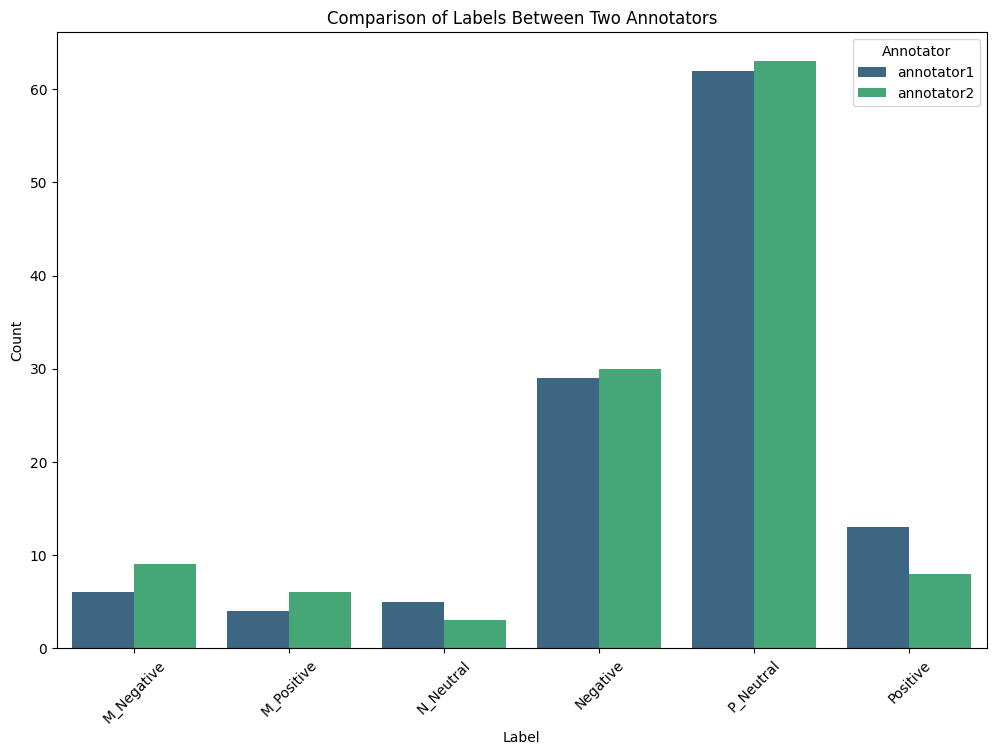

In [31]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=df2, palette='viridis')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

## Label distributions per annotators (all test datasets, non-procedural speech only)


In [32]:
annotator1_non_labels = tests_non['tag_tamara'].value_counts()
annotator2_non_labels = tests_non['tag_katja'].value_counts()

In [33]:
df3 = pd.DataFrame({
    'annotator1': annotator1_non_labels,
    'annotator2': annotator2_non_labels
}).fillna(0)

In [34]:
df3 = df3.reset_index().rename(columns={'index': 'label'})
df3

,label,annotator1,annotator2
0,M_Negative,5,9.0
1,M_Positive,4,6.0
2,N_Neutral,3,0.0
3,Negative,29,29.0
4,P_Neutral,7,9.0
5,Positive,13,8.0


In [35]:
df3 = df3.melt(id_vars='label', var_name='annotator', value_name='count')
df3

,label,annotator,count
0,M_Negative,annotator1,5.0
1,M_Positive,annotator1,4.0
2,N_Neutral,annotator1,3.0
3,Negative,annotator1,29.0
4,P_Neutral,annotator1,7.0
5,Positive,annotator1,13.0
6,M_Negative,annotator2,9.0
7,M_Positive,annotator2,6.0
8,N_Neutral,annotator2,0.0
9,Negative,annotator2,29.0


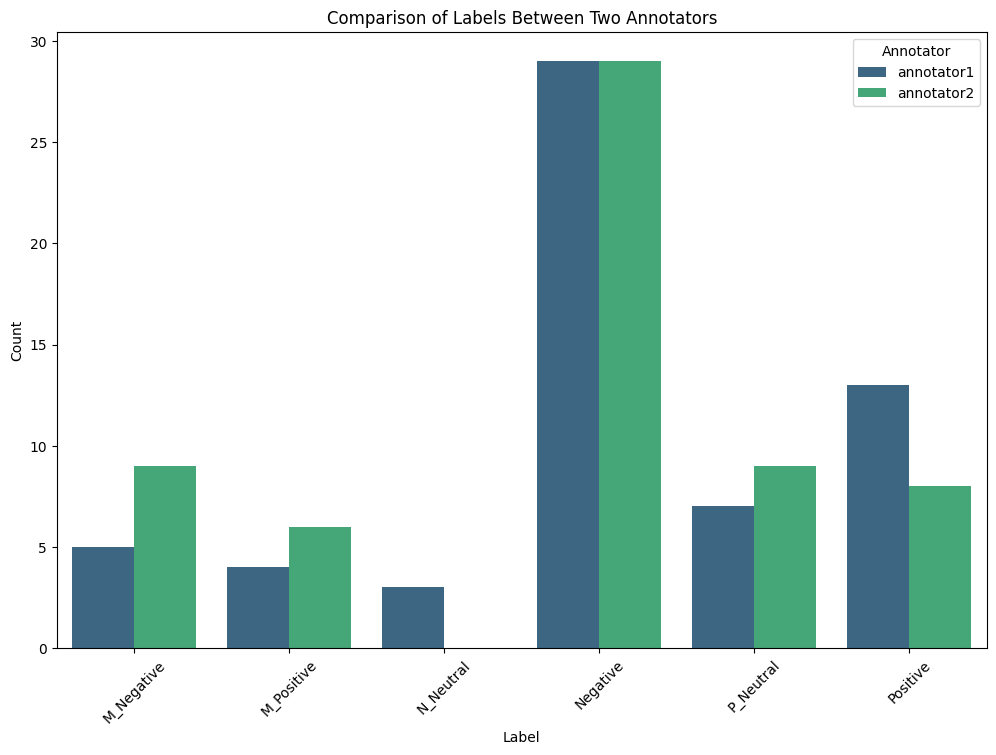

In [36]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=df3, palette='viridis')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

# Kappa scores aggregation 

In [37]:
kappa_scores = {
    "6-level":{
        "full":0.75,
        "non-procedural":0.60
        
    },
    "3-level":{
        "full": 0.79,
        "non-procedural":0.59
    }
}
#Test1+2+3
df_kappa = pd.DataFrame(kappa_scores)

In [38]:
def create_test_df(kappa_scores, test_label):
    df_kappa = pd.DataFrame(kappa_scores).reset_index()
    df_kappa.rename(columns={'index': 'Type'}, inplace=True)
    df_kappa['Phase'] = test_label
    # Reorder columns to place 'Test' before 'Type'
    df_kappa = df_kappa[['Phase', 'Type', '6-level', '3-level']]
    return df_kappa

In [39]:
df_tests = create_test_df(kappa_scores, 'Test1+2+3')
df_tests

,Phase,Type,6-level,3-level
0,Test1+2+3,full,0.75,0.79
1,Test1+2+3,non-procedural,0.60,0.59


In [40]:
df_tests.to_csv("Kappa_scores_test1+2+3.csv", index=False)